In [1]:
from pathlib import Path
from os import environ

ROOT = Path(f"{Path.cwd().parents[1]}/outputs")
basedir = Path(f"{ROOT}/mixpoisson")
datadir = Path(f"{basedir}/data")
outputdir = Path(f"{basedir}/rlct")

if not outputdir.exists():
  outputdir.mkdir(exist_ok=True)
  print(f"Created {outputdir}!")

print(f"Using datadir={datadir}")
print(f"Using outputdir={outputdir}")

Using datadir=/Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixpoisson/data
Using outputdir=/Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixpoisson/rlct


In [2]:
import pandas as pd

dgps_file = f"{datadir}/dgp.csv"
dgps=pd.read_csv(dgps_file, index_col=0).reset_index()
dgps.head()

,dsid,m0,m1,w0,w1
0,regular,15,1,0.75,0.25
1,e-singular,10,5,0.75,0.25
2,singular1,10,5,1.00,0.00
3,singular2,5,5,0.75,0.25


In [3]:
from sklearn_extensions.mixpoisson import PoissonMixture
from scipy_extensions import mixpoisson


def find_truth_by_dsid(dsid: str):
  dgp = dgps.query(f"dsid=='{dsid}'")
  truth = dgp[["m0", "m1", "w0", "w1"]].iloc[0].tolist()
  return truth

def n_components_by_dsid(dsid: str):
  truth = find_truth_by_dsid(dsid)
  half_space = int(np.ceil(len(truth)/2))
  mus = truth[0: half_space]
  weights = truth[half_space: len(truth)]
  return mixpoisson.n_components(mus=mus, weights=weights)

def rlct_by_dsid(dsid: str, k: int):
  n_components0 = n_components_by_dsid(dsid)
  return mixpoisson.rlct(d=1, r=n_components0, k=k)

In [12]:
watanabe_df = pd.read_csv(f"{outputdir}/watanabe_bias.csv")
# filter out the 0.1 and 0.5 d factors
watanabe_df = watanabe_df[watanabe_df['hypers'] != 'c=1,d=2']
watanabe_df = watanabe_df[watanabe_df['hypers'] != 'c=1,d=5']
watanabe_df = watanabe_df[watanabe_df['hypers'] != 'c=1,d=0.5']
watanabe_df = watanabe_df[watanabe_df['hypers'] != 'c=1,d=0.75']
watanabe_df = watanabe_df[watanabe_df['hypers'] != 'c=1,d=20']

In [13]:
watanabe_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7397 entries, 0 to 11608
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dsid                   7397 non-null   object 
 1   regime                 7397 non-null   int64  
 2   n                      7397 non-null   int64  
 3   trial                  7397 non-null   int64  
 4   rlct                   7397 non-null   float64
 5   hypers                 7397 non-null   object 
 6   name                   7397 non-null   object 
 7   chains                 7397 non-null   int64  
 8   draws                  7397 non-null   int64  
 9   tune                   7397 non-null   int64  
 10  mean_divergences       7397 non-null   float64
 11  total_divergences      7397 non-null   int64  
 12  max_divergences        7397 non-null   int64  
 13  divergences_per_chain  7397 non-null   object 
 14  chain_tree_depth       7397 non-null   int64  
 15  duration

In [14]:
watanabe_df["hypers"].unique()

array(['c=1,d=0.1', 'c=1,d=1', 'c=1,d=10', 'c=0.1,d=1', 'c=10,d=1'],
      dtype=object)

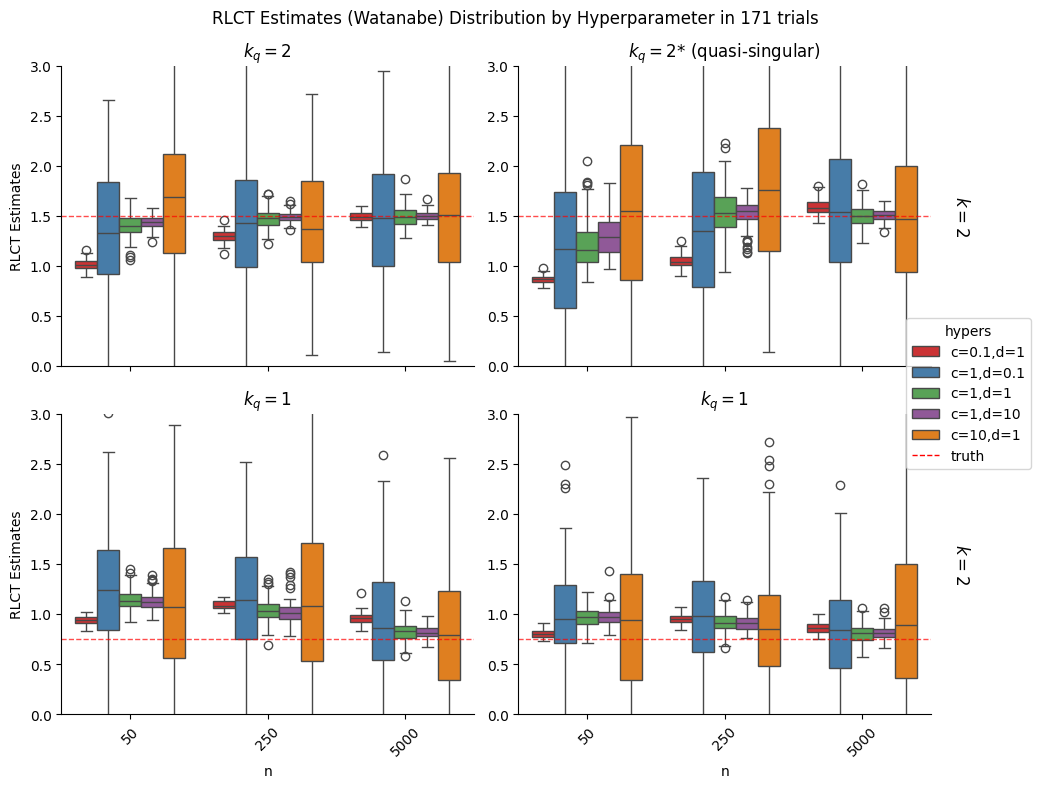

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D

# Define consistent color mapping for hypers
hypers_unique = sorted(watanabe_df['hypers'].unique())
hypers_palette = dict(zip(hypers_unique, sns.color_palette('Set1', n_colors=len(hypers_unique))))

# Label mapping for display
dsid_labels = {
    'regular': '$k_q=2$',
    'e-singular': '$k_q=2$* (quasi-singular)',
    'singular1': '$k_q=1$',
    'singular2': '$k_q=1$'
}

# Row labels (for right side)
row_labels = {
    0: '$k=2$',
    1: '$k=2$',
}

# --- Figure 1: RLCT by Hyperparameters (with ylim) ---
g1 = sns.FacetGrid(
    watanabe_df,
    col='dsid',
    col_wrap=2,
    sharey=False,
    sharex=True,
    height=4,
    aspect=1.3,
    col_order=['regular', 'e-singular', 'singular1', 'singular2'],
)

g1.map_dataframe(sns.boxplot, x='n', y='rlct', hue='hypers', palette=hypers_palette, hue_order=hypers_unique)

k = 2
for idx, (ax, dsid_val) in enumerate(zip(g1.axes.flat, g1.col_names)):
    ax.set_title(dsid_labels.get(dsid_val, dsid_val))
    ax.tick_params(axis='x', rotation=45)
    
    true_val = rlct_by_dsid(dsid_val, k)
    ax.axhline(y=true_val, color='red', linestyle='--', linewidth=1, alpha=0.7)
    
    ax.set_ylim(bottom=0, top=3)
    
    if idx % 2 == 1:
        row_idx = idx // 2
        ax.annotate(
            row_labels.get(row_idx, ''),
            xy=(1.05, 0.5),
            xycoords='axes fraction',
            ha='left',
            va='center',
            fontsize=12,
            fontweight='bold',
            rotation=-90
        )

handles, labels = g1.axes.flat[0].get_legend_handles_labels()
handles.append(Line2D([0], [0], color='red', linestyle='--', linewidth=1))
labels.append('truth')

for ax in g1.axes.flat:
    legend = ax.get_legend()
    if legend:
        legend.remove()

g1.figure.legend(handles, labels, title='hypers', loc='center right')
g1.set_axis_labels('n', 'RLCT Estimates')
g1.figure.suptitle(f'RLCT Estimates (Watanabe) Distribution by Hyperparameter in {len(watanabe_df["trial"].unique())} trials')

plt.tight_layout()
plt.subplots_adjust(right=0.9)
plt.show()

In [16]:
# filter out the 0.1 and 0.5 d factors
watanabe_df = watanabe_df[watanabe_df['hypers'] != 'c=10,d=1']
watanabe_df = watanabe_df[watanabe_df['hypers'] != 'c=1,d=0.1']

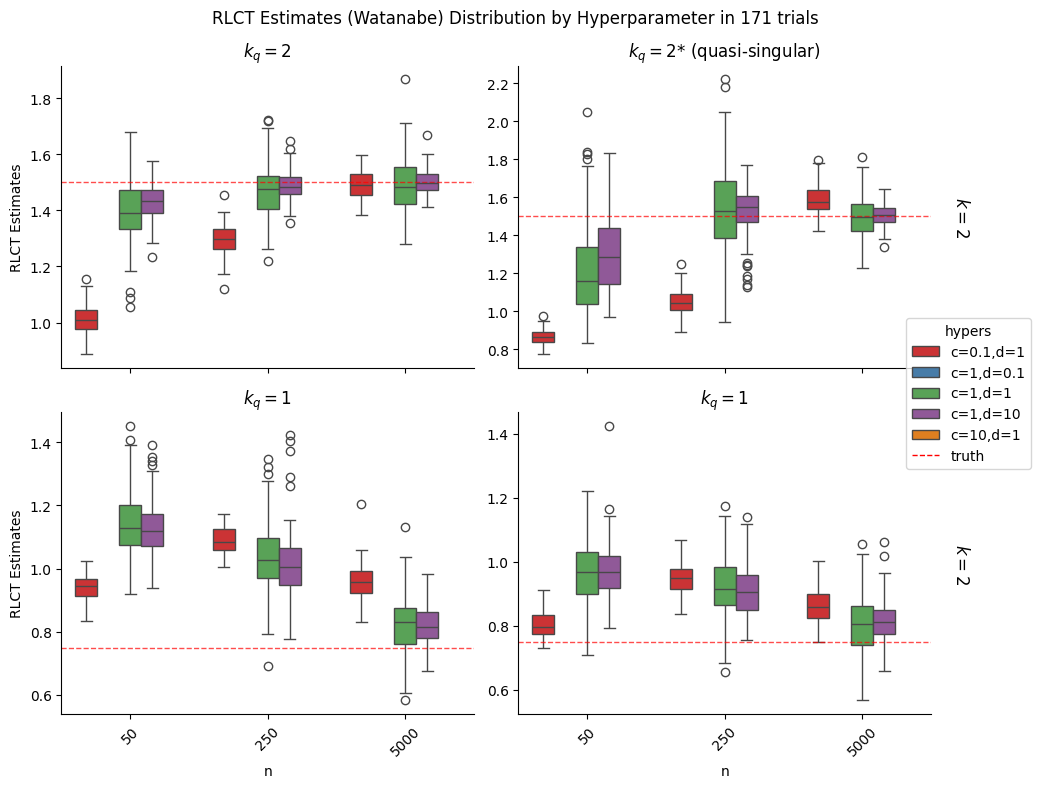

In [17]:
# --- Figure 2: RLCT by Hyperparameters (without ylim) ---
g2 = sns.FacetGrid(
    watanabe_df,
    col='dsid',
    col_wrap=2,
    sharey=False,
    sharex=True,
    height=4,
    aspect=1.3,
    col_order=['regular', 'e-singular', 'singular1', 'singular2'],
)

g2.map_dataframe(sns.boxplot, x='n', y='rlct', hue='hypers', palette=hypers_palette, hue_order=hypers_unique)

k = 2
for idx, (ax, dsid_val) in enumerate(zip(g2.axes.flat, g2.col_names)):
    ax.set_title(dsid_labels.get(dsid_val, dsid_val))
    ax.tick_params(axis='x', rotation=45)
    
    true_val = rlct_by_dsid(dsid_val, k)
    ax.axhline(y=true_val, color='red', linestyle='--', linewidth=1, alpha=0.7)
    
    # No ylim here
    
    if idx % 2 == 1:
        row_idx = idx // 2
        ax.annotate(
            row_labels.get(row_idx, ''),
            xy=(1.05, 0.5),
            xycoords='axes fraction',
            ha='left',
            va='center',
            fontsize=12,
            fontweight='bold',
            rotation=-90
        )

handles, labels = g2.axes.flat[0].get_legend_handles_labels()
handles.append(Line2D([0], [0], color='red', linestyle='--', linewidth=1))
labels.append('truth')

for ax in g2.axes.flat:
    legend = ax.get_legend()
    if legend:
        legend.remove()

g2.figure.legend(handles, labels, title='hypers', loc='center right')
g2.set_axis_labels('n', 'RLCT Estimates')
g2.figure.suptitle(f' Watanabe RLCT Estimates Distribution by Hyperparameter in {len(watanabe_df["trial"].unique())} trials')

plt.tight_layout()
plt.subplots_adjust(right=0.9)
plt.show()

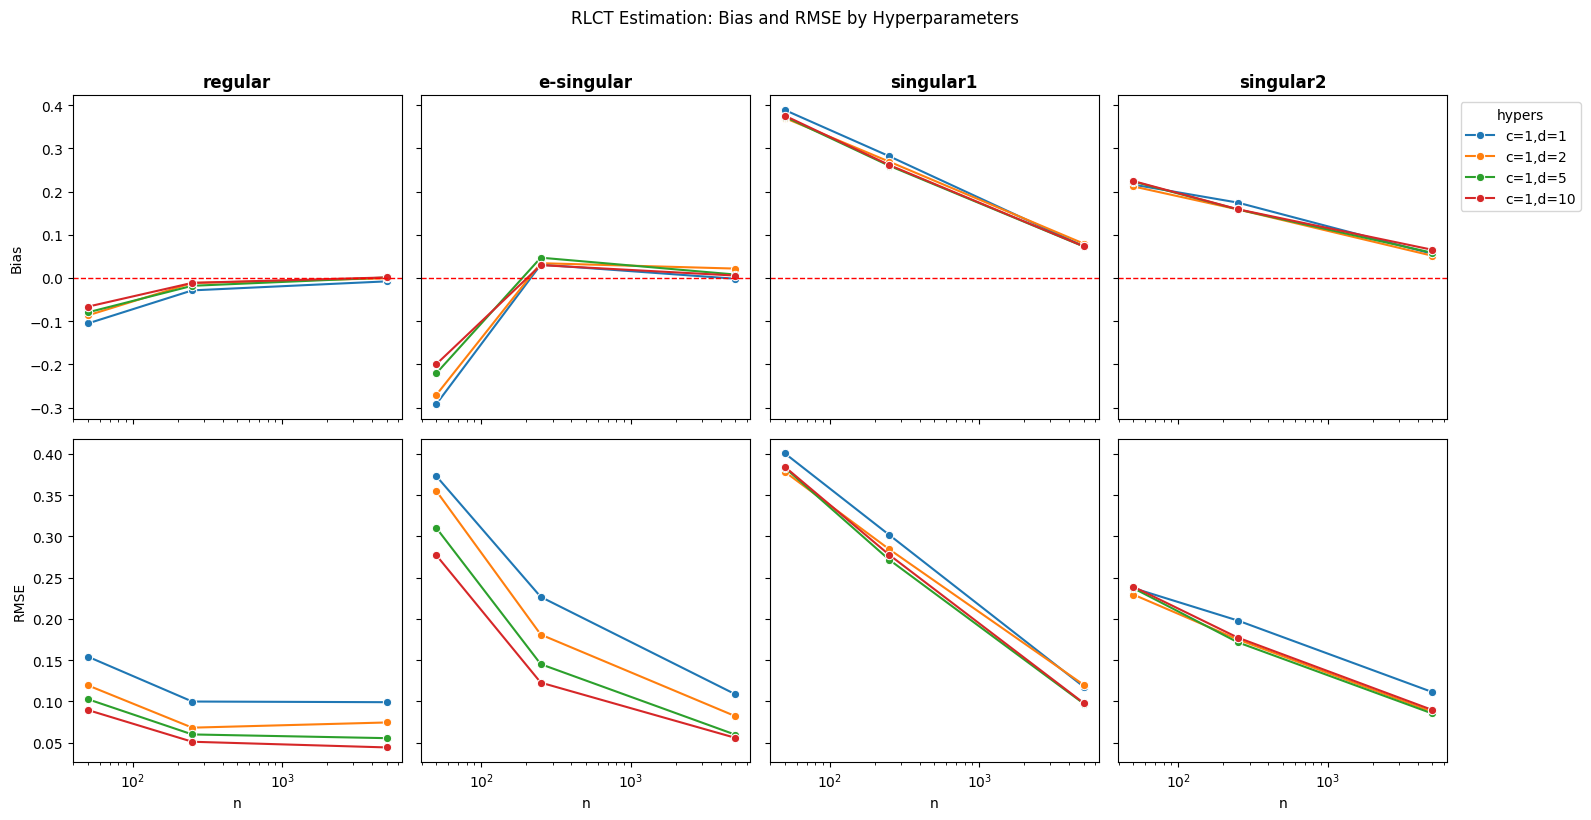

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Compute summary statistics
summary = df.groupby(['dsid', 'n', 'hypers']).agg(
    mean_rlct=('rlct', 'mean'),
    std_rlct=('rlct', 'std'),
    median_rlct=('rlct', 'median')
).reset_index()

# Add true RLCT and compute bias/rmse
summary['true_rlct'] = summary['dsid'].apply(lambda x: rlct_by_dsid(x, k=2))
summary['bias'] = summary['mean_rlct'] - summary['true_rlct']
summary['rmse'] = np.sqrt(summary['bias']**2 + summary['std_rlct']**2)

dsids = ['regular', 'e-singular', 'singular1', 'singular2']

fig, axes = plt.subplots(2, len(dsids), figsize=(4*len(dsids), 8), sharex=True, sharey='row')

for j, dsid in enumerate(dsids):
    data = summary[summary['dsid'] == dsid]
    
    # Top row: Bias
    ax = axes[0, j]
    sns.lineplot(
        data=data,
        x='n',
        y='bias',
        hue='hypers',
        marker='o',
        ax=ax,
        hue_order=['c=1,d=1', 'c=1,d=2', 'c=1,d=5', 'c=1,d=10']
    )
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.set_xscale('log')
    ax.set_title(dsid, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Bias' if j == 0 else '')
    
    if j < len(dsids) - 1:
        ax.get_legend().remove()
    else:
        ax.legend(title='hypers', bbox_to_anchor=(1.02, 1), loc='upper left')
    
    # Bottom row: RMSE
    ax = axes[1, j]
    sns.lineplot(data=data,
                 x='n',
                 y='rmse',
                 hue='hypers',
                 marker='o',
                 ax=ax,
                 hue_order=['c=1,d=1', 'c=1,d=2', 'c=1,d=5', 'c=1,d=10']
                )
    ax.set_xscale('log')
    ax.set_xlabel('n')
    ax.set_ylabel('RMSE' if j == 0 else '')
    ax.get_legend().remove()

plt.suptitle('RLCT Estimation: Bias and RMSE by Hyperparameters', y=1.02)
plt.tight_layout()
plt.show()

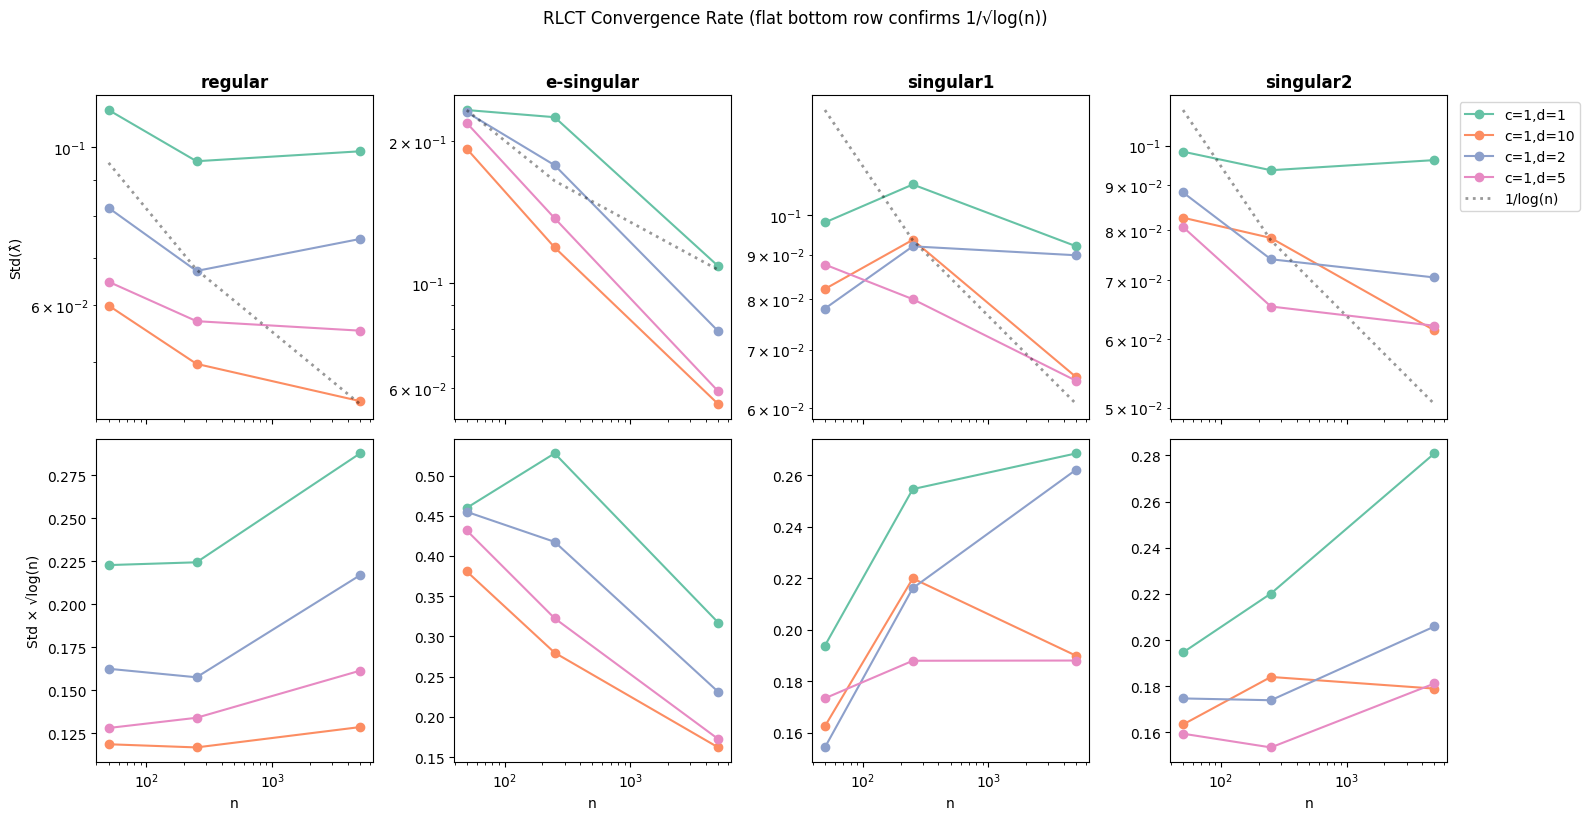

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Compute summary statistics
summary = df.groupby(['dsid', 'n', 'hypers']).agg(
    mean_rlct=('rlct', 'mean'),
    std_rlct=('rlct', 'std')
).reset_index()

summary['true_rlct'] = summary['dsid'].apply(lambda x: rlct_by_dsid(x, k=2))
summary['std_normalized'] = summary['std_rlct'] * np.sqrt(np.log(summary['n']))

dsids = ['regular', 'e-singular', 'singular1', 'singular2']
hypers_list = summary['hypers'].unique()
palette = sns.color_palette('Set2', len(hypers_list))
hyper_colors = dict(zip(hypers_list, palette))

n_range = np.array(sorted(summary['n'].unique()))

fig, axes = plt.subplots(2, len(dsids), figsize=(4*len(dsids), 8), sharex=True)

for j, dsid in enumerate(dsids):
    data = summary[summary['dsid'] == dsid]
    
    # Top row: Std with reference line
    ax = axes[0, j]
    
    for hyper in hypers_list:
        hdata = data[data['hypers'] == hyper].sort_values('n')
        ax.plot(hdata['n'], hdata['std_rlct'], 'o-', 
                label=hyper, color=hyper_colors[hyper])
    
    # Reference line anchored at midpoint
    mid_idx = len(n_range) // 2
    ref_n = n_range[mid_idx]
    ref_std = data.groupby('n')['std_rlct'].mean().iloc[mid_idx]
    
    ax.plot(n_range, ref_std * (np.log(ref_n) / np.log(n_range)), 
            'k:', alpha=0.4, linewidth=2, label='1/log(n)')
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('')
    ax.set_ylabel('Std(λ̂)' if j == 0 else '')
    ax.set_title(dsid, fontweight='bold')
    
    if j == len(dsids) - 1:
        ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    
    # Bottom row: Std × √log(n)
    ax = axes[1, j]
    
    for hyper in hypers_list:
        hdata = data[data['hypers'] == hyper].sort_values('n')
        ax.plot(hdata['n'], hdata['std_normalized'], 'o-', 
                label=hyper, color=hyper_colors[hyper])
    
    ax.set_xscale('log')
    ax.set_xlabel('n')
    ax.set_ylabel('Std × √log(n)' if j == 0 else '')
    ax.get_legend().remove() if ax.get_legend() else None

plt.suptitle('RLCT Convergence Rate (flat bottom row confirms 1/√log(n))', y=1.02)
plt.tight_layout()
plt.show()